## CitySeer: Métricas Configuracionais do Espaço Urbano

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from cityseer.metrics import networks
from cityseer.tools import graphs, io

streets_gpd = gpd.read_file("street_network.gpkg")
streets_gpd = streets_gpd.explode(reset_index=True)
G = io.nx_from_generic_geopandas(streets_gpd)
G_dual = graphs.nx_to_dual(G)

100%|██████████| 47155/47155 [00:27<00:00, 1690.38it/s]
INFO:cityseer.tools.graphs:Merging parallel edges within buffer of 1.
100%|██████████| 47129/47129 [00:02<00:00, 22399.68it/s]
INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 47129/47129 [00:05<00:00, 9295.28it/s] 
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 47129/47129 [03:50<00:00, 204.84it/s]


In [33]:
# prepare the data structures
nodes_gdf, edges_gdf, network_structure = io.network_structure_from_nx(G_dual)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.


100%|██████████| 47129/47129 [00:40<00:00, 1157.65it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 104026 items.


In [34]:
distances = [1000, 2000, 5000]
distances = [1000]

nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
    #minutes=[15, 30, 45],
)
for col in nodes_gdf.columns:
    if col.startswith("cc_"):
        nodes_gdf[f"{col}_not"] = nodes_gdf[col]

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 47129/47129 [00:25<00:00, 1875.86it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.


In [35]:
network_structure, stops, avg_stop_pairs = io.add_transport_gtfs(
    "madrid_metro",
    network_structure,
    nodes_gdf.crs,
)

INFO:cityseer.tools.io:Loading GTFS data from madrid_metro
INFO:cityseer.tools.io:Loaded 1050 stops and 2216 stop times
INFO:cityseer.tools.io:Adding GTFS stops to network nodes (with street linking logic).
100%|██████████| 1050/1050 [00:00<00:00, 4696.40it/s]
INFO:cityseer.tools.io:Generating segment durations between stops.
INFO:cityseer.tools.io:Adding GTFS segments to network edges.
100%|██████████| 262/262 [00:00<00:00, 10479.36it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 104026 items.


In [36]:
# convert stops to geopandas
stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]),
    crs=4326,  # Adjust the CRS to suit your data if needed
)
stops_gdf = stops_gdf.to_crs(streets_gpd.crs.to_epsg())

In [37]:
nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
    #minutes=[15, 30, 45]
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 47129/47129 [00:29<00:00, 1614.04it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.


In [40]:
from sklearn.preprocessing import minmax_scale

nodes_gdf["cc_harmonic_1000_diff"] = (
    nodes_gdf["cc_harmonic_1000"] - nodes_gdf["cc_harmonic_1000_not"]
)

vmax = nodes_gdf["cc_harmonic_1000_not"].max()
vmax=5

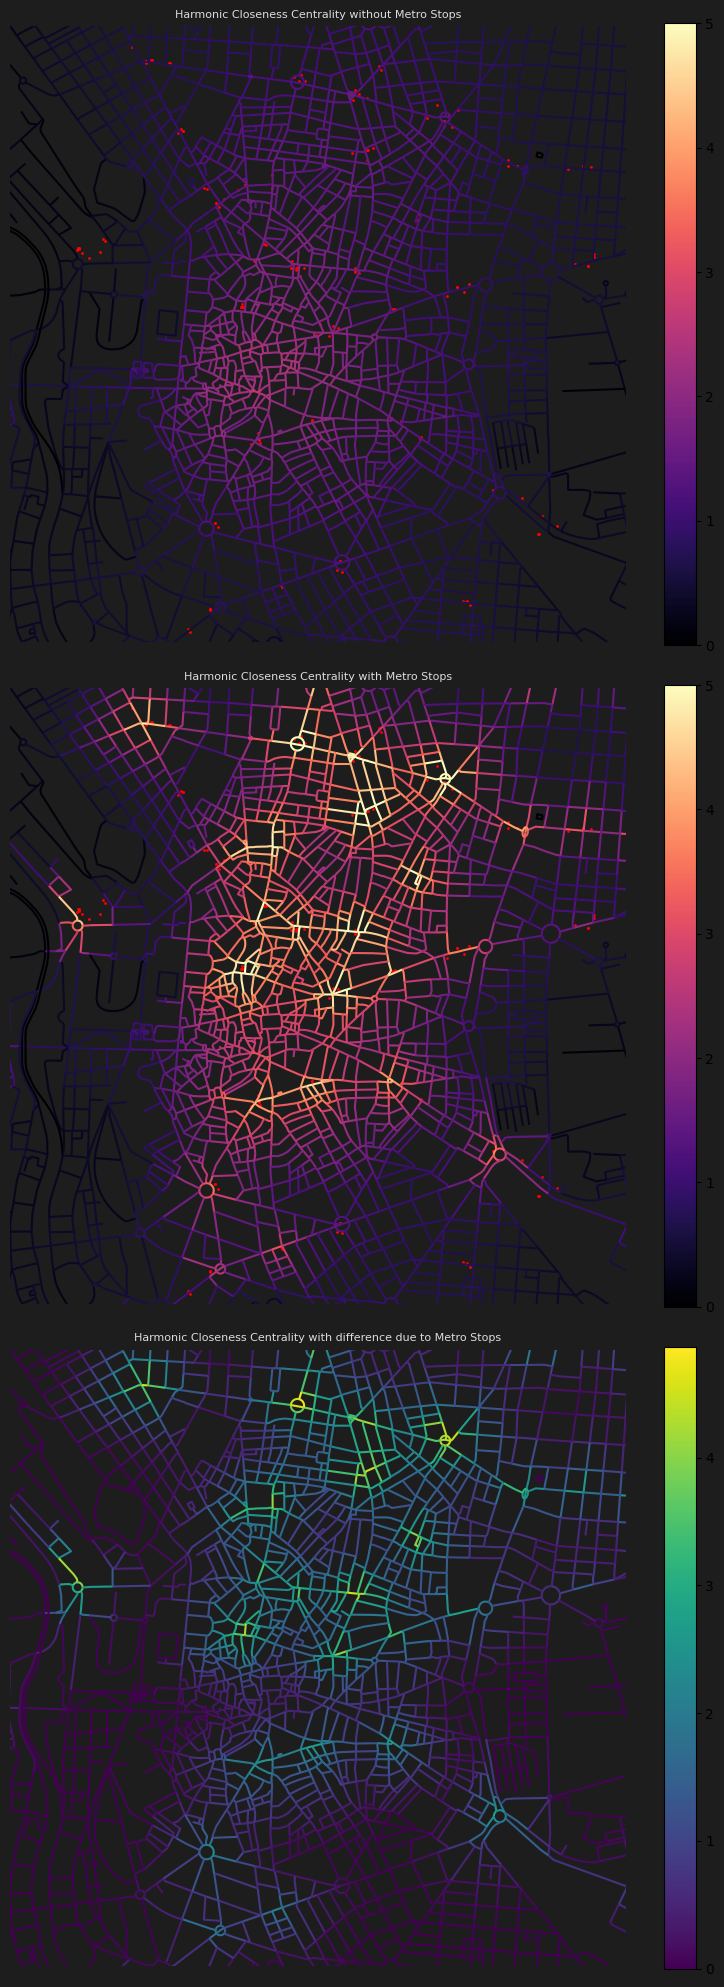

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(8, 20), facecolor="#1d1d1d")

nodes_gdf.plot(
    column="cc_harmonic_1000_not",
    cmap="magma",
    legend=True,
    ax=axes[0],
    vmax=vmax,
)
axes[0].set_title(
    "Harmonic Closeness Centrality without Metro Stops",
    fontsize=8,
    color="#ddd",
)
stops_gdf.plot(ax=axes[0], color="red", markersize=1)

nodes_gdf.plot(
    column="cc_harmonic_1000",
    cmap="magma",
    legend=True,
    ax=axes[1],
    vmax=vmax,
)
axes[1].set_title(
    "Harmonic Closeness Centrality with Metro Stops",
    fontsize=8,
    color="#ddd",
)
stops_gdf.plot(ax=axes[1], color="red", markersize=1)

nodes_gdf.plot(
    column="cc_harmonic_1000_diff",
    cmap="viridis",
    legend=True,
    ax=axes[2],
)
axes[2].set_title(
    "Harmonic Closeness Centrality with difference due to Metro Stops",
    fontsize=8,
    color="#ddd",
)

for ax in axes:
    ax.set_xlim(438500, 438500 + 3500)
    ax.set_ylim(4472500, 4472500 + 3500)
    ax.axis(False)

plt.tight_layout()

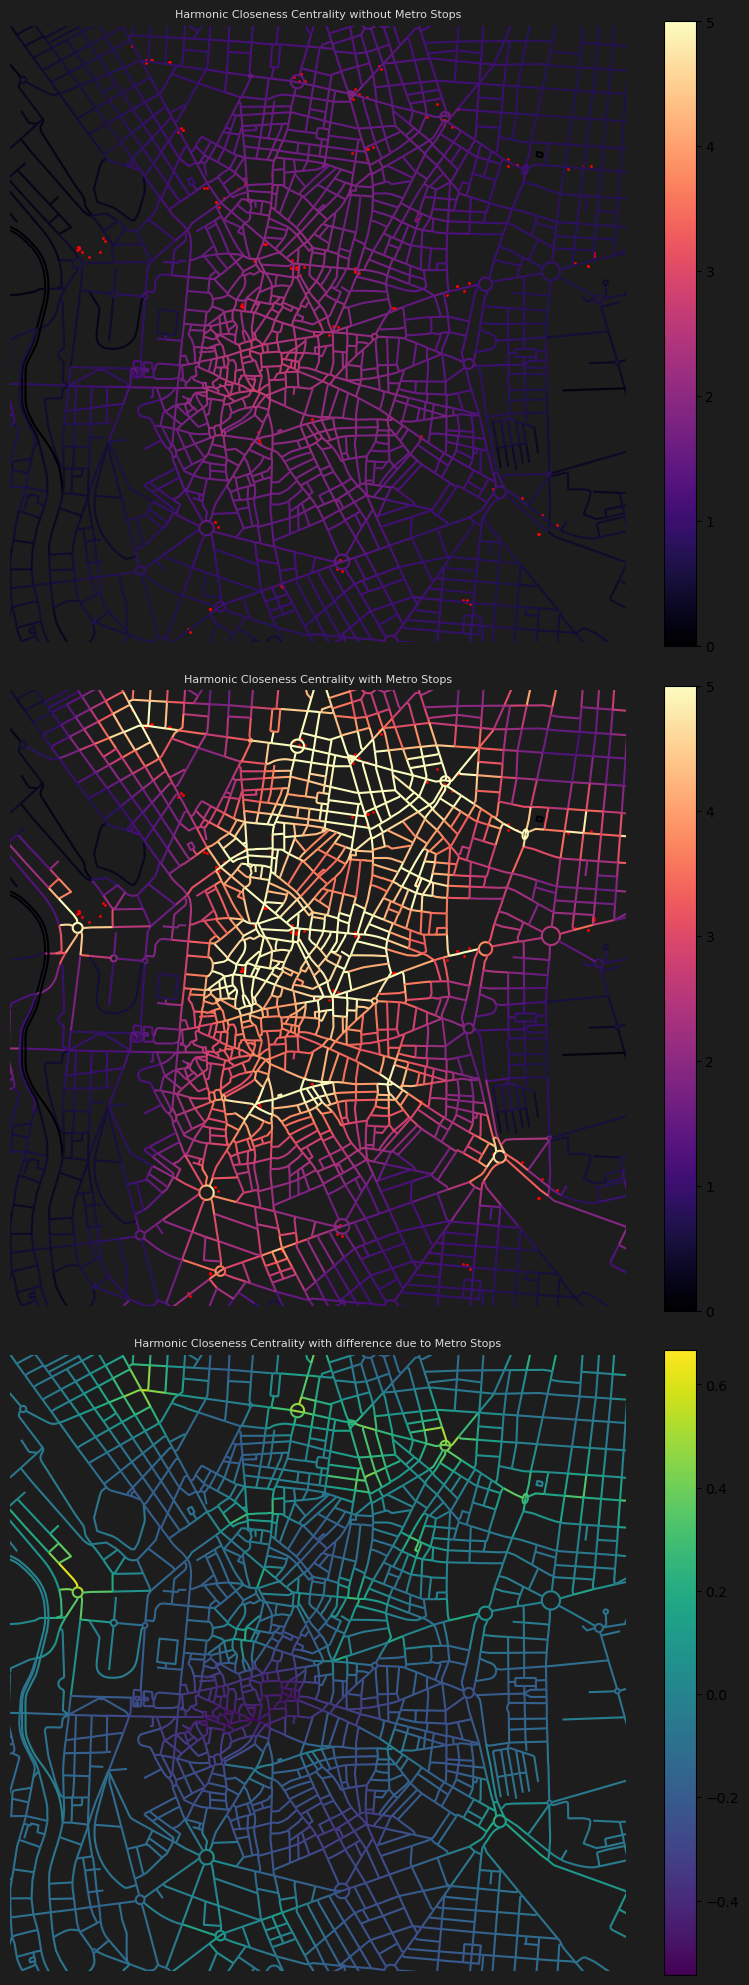

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 20), facecolor="#1d1d1d")

nodes_gdf.plot(
    column="cc_harmonic_1000_not",
    cmap="magma",
    legend=True,
    ax=axes[0],
    vmax=vmax,
)
axes[0].set_title(
    "Harmonic Closeness Centrality without Metro Stops",
    fontsize=8,
    color="#ddd",
)
stops_gdf.plot(ax=axes[0], color="red", markersize=1)

nodes_gdf.plot(
    column="cc_harmonic_1000",
    cmap="magma",
    legend=True,
    ax=axes[1],
    vmax=vmax,
)
axes[1].set_title(
    "Harmonic Closeness Centrality with Metro Stops",
    fontsize=8,
    color="#ddd",
)
stops_gdf.plot(ax=axes[1], color="red", markersize=1)

nodes_gdf.plot(
    column="cc_harmonic_1000_diff",
    cmap="viridis",
    legend=True,
    ax=axes[2],
)
axes[2].set_title(
    "Harmonic Closeness Centrality with difference due to Metro Stops",
    fontsize=8,
    color="#ddd",
)

for ax in axes:
    ax.set_xlim(438500, 438500 + 3500)
    ax.set_ylim(4472500, 4472500 + 3500)
    ax.axis(False)

plt.tight_layout()